# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedBaggingClassifier

# 2. Load the dataset (with features)

In [2]:
df = pd.read_csv("data/BLE_FE.csv")
if 'window_start' in df.columns:
    df = df.drop(columns='window_start')

In [33]:
df.head()

,count_1,count_2,count_3,count_4,count_5,count_6,count_7,count_8,count_9,count_10,...,b2_max,b2_min,b2_norm,b3_mean,b3_std,b3_max,b3_min,b3_norm,unique_beacon_count,location
0,0,0,0,214,0,68,17,0,68,0,...,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9,kitchen
1,0,0,0,214,0,68,17,0,68,0,...,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9,kitchen
2,0,0,0,68,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,7,cafeteria
3,0,0,0,68,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,9,cafeteria
4,0,0,0,136,17,0,34,0,47,0,...,-92.0,-95.0,640.694935,-95.0,3.045115,-92.0,-98.0,554.216564,11,cafeteria


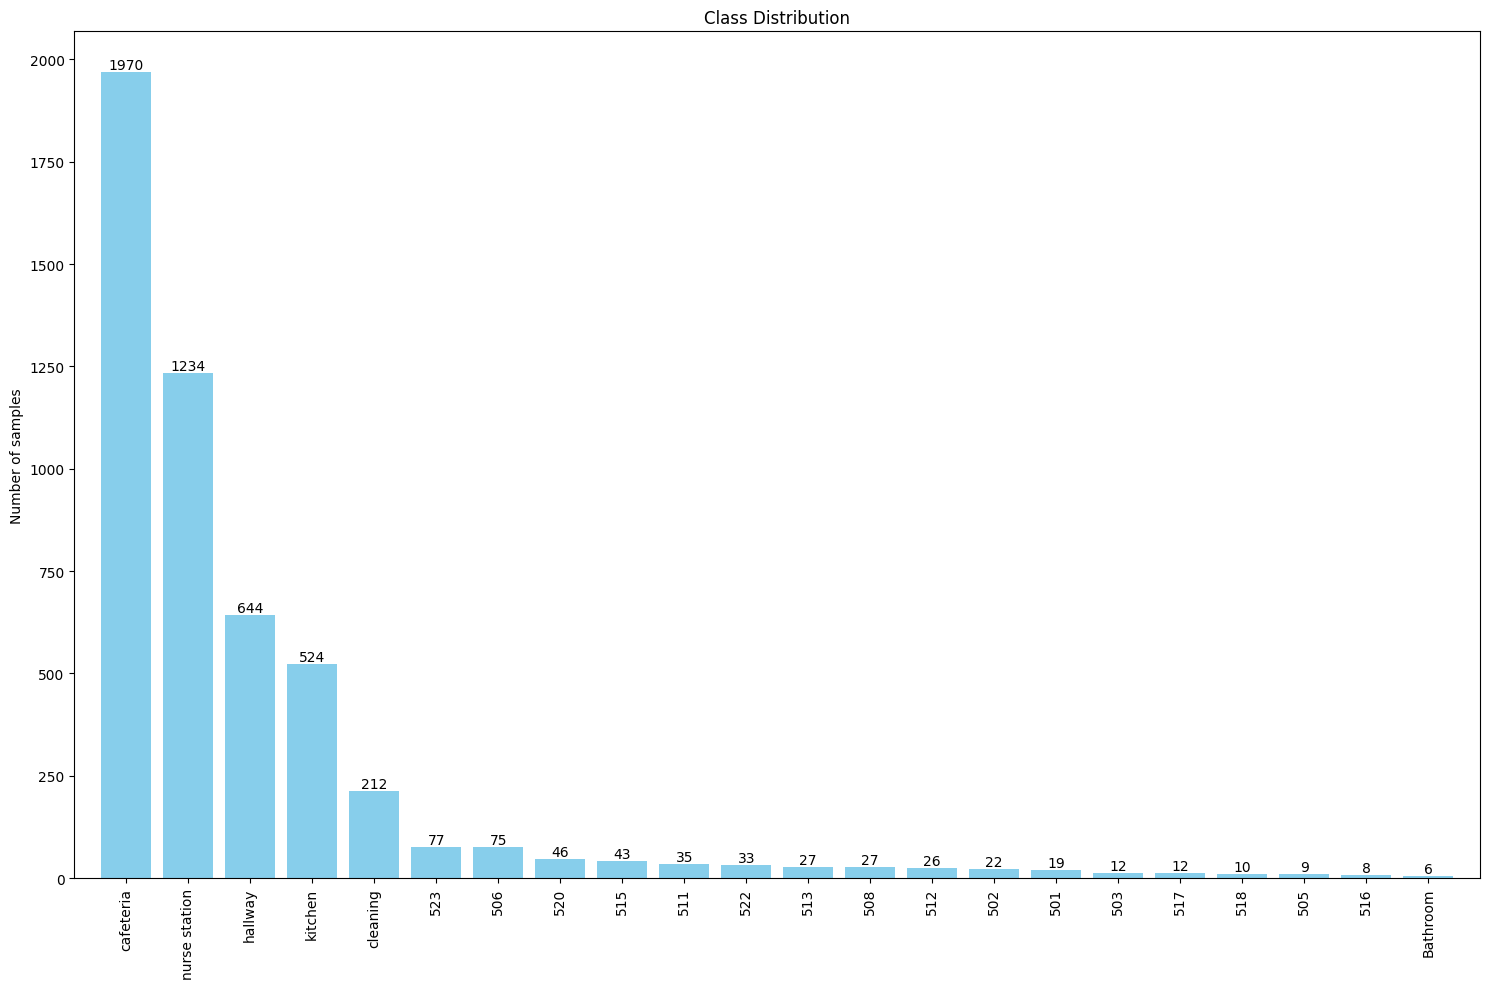

In [4]:
distribution = df['location'].value_counts()

plt.figure(figsize=(15, 10))

bars = plt.bar(distribution.index, distribution.values, color='skyblue', width=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:}', ha='center', va='bottom')

plt.xticks(rotation=90)
plt.margins(x=0.02)
plt.ylabel('Number of samples')
plt.title('Class Distribution')
plt.tight_layout()
plt.savefig("../figs/class_distribution.png")
plt.show()

In [5]:
percentages = df['location'].value_counts(normalize=True) * 100
print(percentages)

location
cafeteria        38.848353
nurse station    24.334451
hallway          12.699665
kitchen          10.333268
cleaning          4.180635
523               1.518438
506               1.478998
520               0.907119
515               0.847959
511               0.690199
522               0.650759
513               0.532439
508               0.532439
512               0.512719
502               0.433839
501               0.374680
503               0.236640
517               0.236640
518               0.197200
505               0.177480
516               0.157760
Bathroom          0.118320
Name: proportion, dtype: float64


In [6]:
y = df['location']

In [7]:
X = df.drop(columns='location')
X.head()

,count_1,count_2,count_3,count_4,count_5,count_6,count_7,count_8,count_9,count_10,...,b2_std,b2_max,b2_min,b2_norm,b3_mean,b3_std,b3_max,b3_min,b3_norm,unique_beacon_count
0,0,0,0,214,0,68,17,0,68,0,...,3.225366,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9
1,0,0,0,214,0,68,17,0,68,0,...,3.225366,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9
2,0,0,0,68,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,7
3,0,0,0,68,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,9
4,0,0,0,136,17,0,34,0,47,0,...,1.247755,-92.0,-95.0,640.694935,-95.0,3.045115,-92.0,-98.0,554.216564,11


In [8]:
split_idx = int(0.8 * len(X))

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y[:split_idx]
y_test  = y[split_idx:]

In [9]:
missing_classes = set(np.unique(y_train)) - set(np.unique(y_test))
print("Classes missing in test:", missing_classes)

Classes missing in test: {'511', '520', '516', '502', '512', '503', '501', '522'}


In [10]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
np.unique(y_train_encoded)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21])

In [11]:
y_test_encoded = le.transform(y_test)
np.unique(y_test_encoded)

array([ 3,  4,  5,  8,  9, 11, 12, 15, 16, 17, 18, 19, 20, 21])

In [12]:
class_counts = np.bincount(y_train_encoded)
class_freq = class_counts / class_counts.sum()

class_weights = {
    c: 1.0 / np.log(1.2 + class_freq[c])
    for c in range(len(class_counts))
}

sample_weights = np.array([class_weights[y] for y in y_train_encoded])

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", X.columns)
    ]
)

In [14]:
rf = RandomForestClassifier(
    criterion='entropy',
    n_estimators=800,
    max_depth=15,            
    min_samples_leaf=3,      
    min_samples_split=20,
    max_features="sqrt",
    class_weight='balanced',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", rf)
])

pipeline.fit(X_train, y_train_encoded)

y_pred = pipeline.predict(X_test)

In [15]:
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    min_child_weight=15,   
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,        
    reg_lambda=2.0,
    objective="multi:softprob",
    tree_method="hist",
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])

pipeline.fit(X_train, y_train_encoded, classifier__sample_weight=sample_weights)

probs = pipeline.predict_proba(X_test)
def confidence_smooth(probs, k):
    T, C = probs.shape
    smoothed = np.zeros_like(probs)
    conf = probs.max(axis=1)

    for t in range(T):
        start = max(0, t - k)
        end = min(T, t + k + 1)
        smoothed[t] = np.average(
            probs[start:end],
            axis=0,
            weights=conf[start:end]
        )

    return smoothed
k = 10
smoothed_probs = confidence_smooth(probs, k)
y_pred = smoothed_probs.argmax(axis=1)

In [16]:
accuracy = accuracy_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred, average='macro')
precision = precision_score(y_test_encoded, y_pred, average='macro', zero_division=0.0)
recall = recall_score(y_test_encoded, y_pred, average='macro', zero_division=0.0)

print(f"Accuracy: {accuracy:.2f}")
print(f"Macro F1 score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.59
Macro F1 score: 0.21
Precision: 0.23
Recall: 0.21


In [17]:
f1_per_class = f1_score(y_test_encoded, y_pred, average=None)
test_classes = np.unique(le.inverse_transform(y_test_encoded))
sorted_idx = np.argsort(f1_per_class)[::-1]
sorted_classes = [test_classes[i] for i in sorted_idx]
sorted_f1 = [f1_per_class[i] for i in sorted_idx]

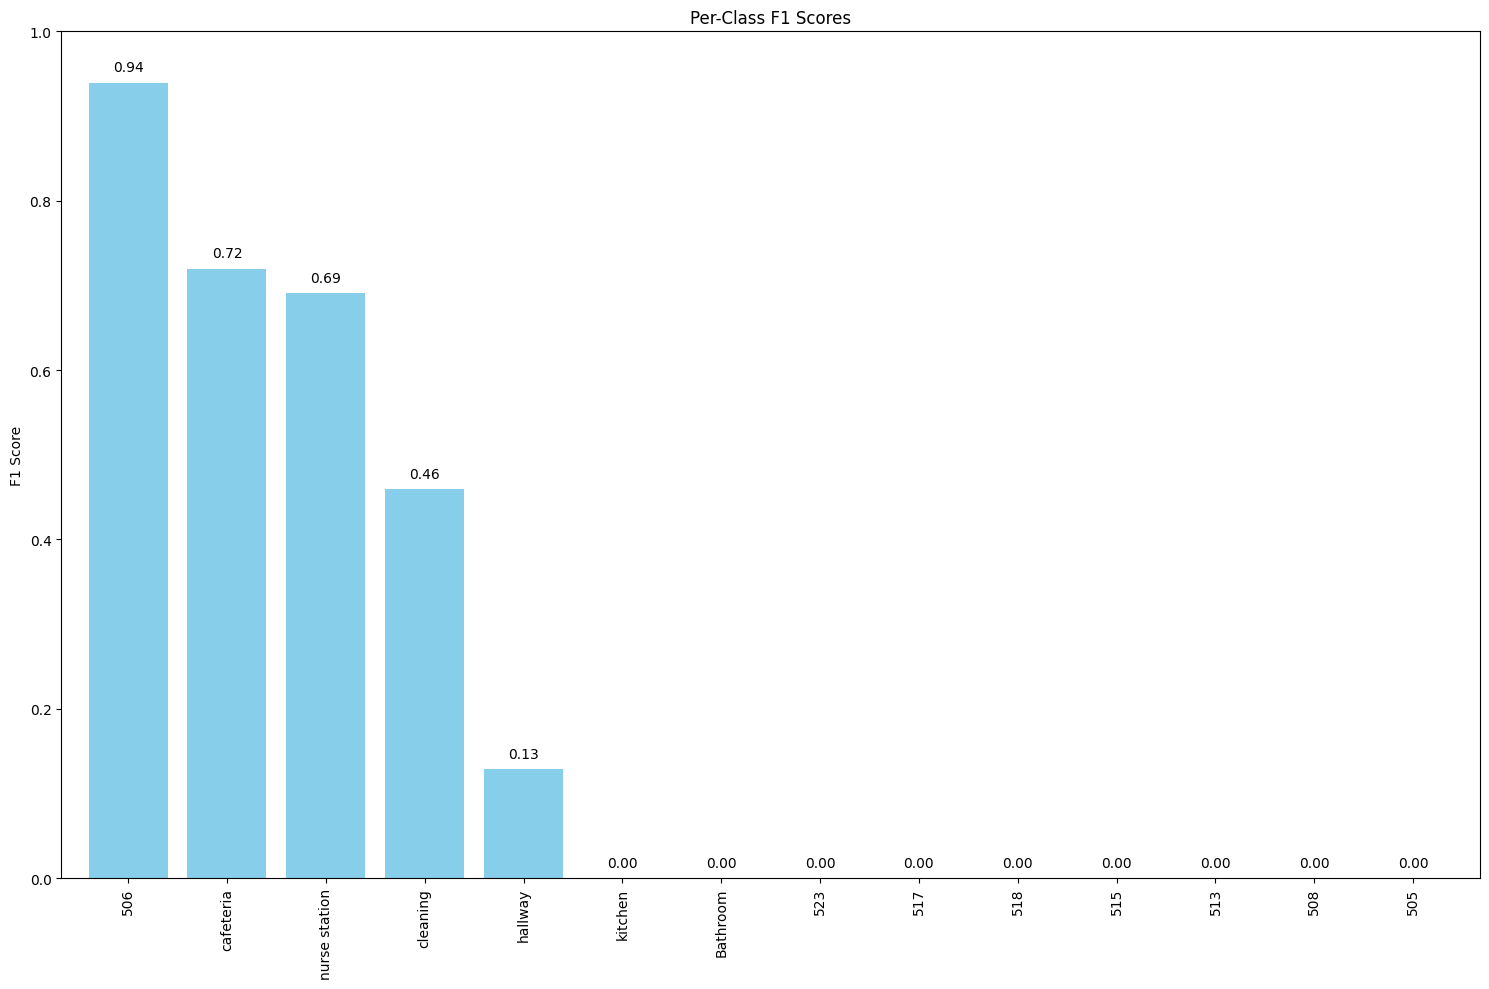

In [18]:
plt.figure(figsize=(15, 10))

bars = plt.bar(sorted_classes, sorted_f1, color='skyblue', width=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

plt.xticks(rotation=90)
plt.margins(x=0.02)
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.title('Per-Class F1 Scores')
plt.tight_layout()
plt.savefig("../figs/per_class_f1.png")

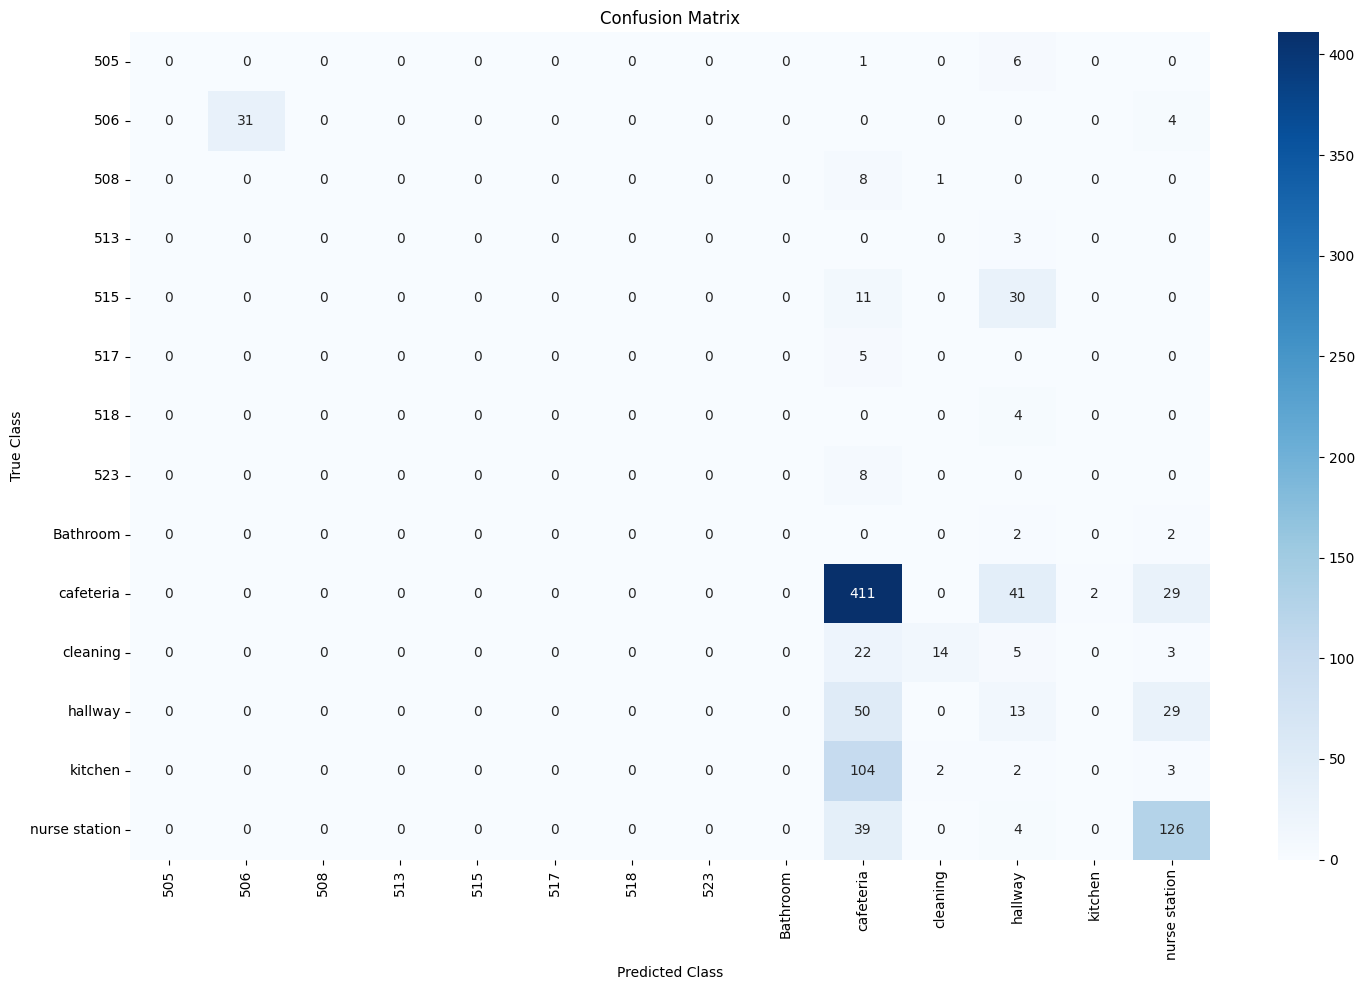

In [19]:
cm = confusion_matrix(y_test_encoded, y_pred, labels=np.unique(y_test_encoded))
cm_df = pd.DataFrame(cm, index=test_classes, columns=test_classes)
plt.figure(figsize=(15, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig("../figs/confusion_matrix.png")
plt.show()

# 3. Process Raw BLE Test Data and Generate Predictions

In [25]:
# Load raw test data and apply feature engineering
# Raw columns: user_id, timestamp, name, mac_address, RSSI, power

# Load the raw BLE test data
raw_test_df = pd.read_csv("BLE_Test_predict.csv")
print(f"Raw test data shape: {raw_test_df.shape}")
print(f"Raw test columns: {raw_test_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(raw_test_df.head())

# Store original data for later
original_test_df = raw_test_df.copy()

# Convert timestamp to datetime if needed
if 'timestamp' in raw_test_df.columns:
    raw_test_df['timestamp'] = pd.to_datetime(raw_test_df['timestamp'], errors='coerce')
    print(f"\nTimestamp range: {raw_test_df['timestamp'].min()} to {raw_test_df['timestamp'].max()}")


Raw test data shape: (62222, 6)
Raw test columns: ['Unnamed: 0', 'user_id', 'timestamp', 'mac address', 'RSSI', 'power']

First few rows:
   Unnamed: 0  user_id            timestamp  mac address  RSSI       power
0         766       90  2023-04-14 10:01:40            7   -97 -2147483648
1         764       90  2023-04-14 10:01:40            7   -97 -2147483648
2         765       90  2023-04-14 10:01:40            7   -97 -2147483648
3         762       90  2023-04-14 10:01:40            7   -97 -2147483648
4         761       90  2023-04-14 10:01:40            7   -97 -2147483648

Timestamp range: 2023-04-14 10:01:40 to 2023-04-14 17:11:08


In [ ]:
# Define beacon mapping
# The test data already has beacon IDs (1-25) in the 'mac address' column
# So we just need a simple mapping from beacon_id -> beacon_id
beacon_ids = list(range(1, 26))  # 1-25
mac_to_id = {i: i for i in beacon_ids}  # Identity mapping since already beacon IDs

print(f"Number of known beacons: {len(mac_to_id)}")
print(f"Beacon IDs: {beacon_ids}")
print(f"Feature columns in training data: {X.columns.tolist()[:5]}...")  # Show first 5


Number of known beacons: 25
Feature columns in training data: ['count_1', 'count_2', 'count_3', 'count_4', 'count_5']...


In [34]:
# Apply sliding window feature engineering to raw test data
# Same logic as BLE_FE.ipynb

window_seconds = 10
step_seconds = 5
window_td = pd.Timedelta(seconds=window_seconds)
step_td = pd.Timedelta(seconds=step_seconds)

def _l2_norm(values):
    arr = values.to_numpy(dtype=float, copy=False)
    return float(np.linalg.norm(arr))

# Group by user and process windows
def engineer_features_for_user(user_data, user_start_idx, mac_to_id, X_columns):
    """Apply feature engineering to a user's data and track original row indices"""
    user_data = user_data.sort_values('timestamp').reset_index(drop=True)
    
    windows = []
    window_starts = []
    row_to_window = []  # Track which window each row belongs to
    
    # Create sliding windows
    start_time = user_data['timestamp'].min()
    end_time = user_data['timestamp'].max()
    
    current_time = start_time
    window_idx = 0
    while current_time + window_td <= end_time:
        window_end = current_time + window_td
        window_data = user_data[(user_data['timestamp'] >= current_time) & 
                               (user_data['timestamp'] < window_end)]
        
        if len(window_data) > 0:
            # Map original row indices to this window
            original_indices = window_data.index.tolist()
            for orig_idx in original_indices:
                row_to_window.append(user_start_idx + orig_idx)
            
            # Count beacons
            beacon_counts = {}
            rssi_data = {}
            power_data = {}
            
            for _, row in window_data.iterrows():
                # In test data, 'mac address' column already contains beacon_id (1-25)
                mac = row['mac_address'] if 'mac_address' in row.index else row.get('mac address')
                try:
                    beacon_id = int(mac)  # Convert to int directly
                    if 1 <= beacon_id <= 25:  # Valid beacon ID
                        beacon_counts[beacon_id] = beacon_counts.get(beacon_id, 0) + 1
                        if beacon_id not in rssi_data:
                            rssi_data[beacon_id] = []
                            power_data[beacon_id] = []
                        rssi_data[beacon_id].append(row['RSSI'])
                        power_data[beacon_id].append(row['power'])
                except (ValueError, TypeError):
                    # Skip if not a valid beacon ID
                    pass
            
            # Create feature vector
            features = {}
            
            # Count features for known beacons
            for bid in beacon_ids:
                features[f'count_{bid}'] = beacon_counts.get(bid, 0)
            
            # Get top 3 beacons by RSSI strength
            if rssi_data:
                beacon_rssi_max = {bid: max(rssi_data[bid]) for bid in rssi_data}
                top_3_beacons = sorted(beacon_rssi_max.items(), key=lambda x: x[1], reverse=True)[:3]
                
                for i, (bid, _) in enumerate(top_3_beacons):
                    features[f'b{i+1}'] = bid
                    features[f'b{i+1}_rssi_mean'] = np.mean(rssi_data[bid])
                    features[f'b{i+1}_rssi_std'] = np.std(rssi_data[bid])
                    features[f'b{i+1}_rssi_max'] = np.max(rssi_data[bid])
                    features[f'b{i+1}_rssi_min'] = np.min(rssi_data[bid])
                    features[f'b{i+1}_rssi_l2'] = _l2_norm(pd.Series(rssi_data[bid]))
                    features[f'b{i+1}_power_mean'] = np.mean(power_data[bid])
                    features[f'b{i+1}_power_std'] = np.std(power_data[bid])
                    features[f'b{i+1}_power_max'] = np.max(power_data[bid])
                    features[f'b{i+1}_power_min'] = np.min(power_data[bid])
                    features[f'b{i+1}_power_l2'] = _l2_norm(pd.Series(power_data[bid]))
                
                # Fill remaining b2, b3 if less than 3 beacons
                for i in range(len(top_3_beacons), 3):
                    features[f'b{i+1}'] = 0
                    for stat in ['rssi_mean', 'rssi_std', 'rssi_max', 'rssi_min', 'rssi_l2',
                                'power_mean', 'power_std', 'power_max', 'power_min', 'power_l2']:
                        features[f'b{i+1}_{stat}'] = 0
            
            # Unique beacon count
            features['unique_beacon_count'] = len(rssi_data)
            
            windows.append(features)
            window_starts.append(current_time)
            window_idx += 1
        
        current_time += step_td
    
    if windows:
        result_df = pd.DataFrame(windows)
        # Add missing columns with 0s
        for col in X_columns:
            if col not in result_df.columns:
                result_df[col] = 0
        result_df = result_df[X_columns]  # Ensure column order matches
        return result_df, window_starts, row_to_window
    else:
        return None, None, []

# Process test data
print("Applying feature engineering to raw test data...")
print("This may take a moment...")

# Group by user_id if available
if 'user_id' in raw_test_df.columns:
    users = raw_test_df['user_id'].unique()
    all_features = []
    all_window_starts = []
    all_row_to_window = []  # Track which window each row belongs to
    row_offset = 0
    
    for user in users:
        user_data = raw_test_df[raw_test_df['user_id'] == user].copy()
        features, starts, row_to_window = engineer_features_for_user(
            user_data, row_offset, mac_to_id, X.columns
        )
        if features is not None:
            all_features.append(features)
            all_window_starts.extend(starts)
            all_row_to_window.extend(row_to_window)
        row_offset += len(user_data)
    
    if all_features:
        X_test_engineered = pd.concat(all_features, ignore_index=True)
        # Create mapping from window index to row indices
        window_idx = 0
        window_to_rows = {}
        for row_idx in all_row_to_window:
            # Count how many times each window appears
            if row_idx not in range(len(raw_test_df)):
                continue
        
        print(f"Engineered features shape: {X_test_engineered.shape}")
        print(f"Original test data shape: {raw_test_df.shape}")
        print(f"First row of engineered features:")
        print(X_test_engineered.iloc[0])
    else:
        print("No features could be engineered from test data")
        X_test_engineered = None
        all_row_to_window = []
else:
    features, starts, row_to_window = engineer_features_for_user(
        raw_test_df, 0, mac_to_id, X.columns
    )
    X_test_engineered = features
    all_window_starts = starts
    all_row_to_window = row_to_window
    print(f"Engineered features shape: {X_test_engineered.shape}")
    print(f"Original test data shape: {raw_test_df.shape}")

# Create a mapping from original row index to window prediction
# row_to_window contains (row_index, window_index) pairs implicitly
# We need to build a proper mapping
window_to_rows = {}  # window_idx -> list of original row indices
for window_idx, orig_row_idx in enumerate(all_row_to_window):
    if window_idx not in window_to_rows:
        window_to_rows[window_idx] = []
    window_to_rows[window_idx].append(orig_row_idx)


Applying feature engineering to raw test data...
This may take a moment...
Engineered features shape: (1858, 44)
Original test data shape: (62222, 6)
First row of engineered features:
count_1                 0
count_2                 0
count_3                 0
count_4                 6
count_5                 0
count_6                 0
count_7                36
count_8                18
count_9                12
count_10                0
count_11                6
count_12                0
count_13                0
count_14                0
count_15                0
count_16                0
count_17                0
count_18               12
count_19                0
count_20               12
count_21                0
count_22                6
count_23                0
count_24                0
count_25                0
b1                      7
b2                      8
b3                     20
b1_mean                 0
b1_std                  0
b1_max                  0
b1_min    

In [35]:
# Generate predictions on engineered test data
if X_test_engineered is not None:
    print("="*60)
    print("GENERATING PREDICTIONS ON RAW TEST DATA")
    print("="*60)
    
    # Get predictions from both models
    rf_pred_raw = pipeline.predict(X_test_engineered)
    
    # Use XGBoost with smoothing
    xgb_probs_raw = pipeline.predict_proba(X_test_engineered)
    xgb_smoothed_raw = confidence_smooth(xgb_probs_raw, k=10)
    xgb_pred_raw = xgb_smoothed_raw.argmax(axis=1)
    
    # Convert predictions back to location names
    rf_locations = le.inverse_transform(rf_pred_raw)
    xgb_locations = le.inverse_transform(xgb_pred_raw)
    
    print(f"Generated {len(rf_locations)} window-level predictions")
    print(f"Unique predicted locations: {np.unique(xgb_locations)}")
    
    # Map window predictions back to individual rows
    rf_pred_all_rows = np.zeros(len(original_test_df), dtype=object)
    xgb_pred_all_rows = np.zeros(len(original_test_df), dtype=object)
    
    # For each window, assign its prediction to all rows that belong to it
    for window_idx in range(len(rf_locations)):
        if window_idx in window_to_rows:
            for orig_row_idx in window_to_rows[window_idx]:
                if orig_row_idx < len(original_test_df):
                    rf_pred_all_rows[orig_row_idx] = rf_locations[window_idx]
                    xgb_pred_all_rows[orig_row_idx] = xgb_locations[window_idx]
    
    # Use XGBoost predictions as primary (better performance)
    final_predictions = xgb_pred_all_rows
    
    print(f"Mapped predictions to {len(final_predictions)} individual rows")
    print(f"Rows with predictions: {(final_predictions != '0').sum()}")
    
    # Create output dataframe with original data + Location column
    output_df = original_test_df.copy()
    output_df['Location'] = final_predictions
    
    print(f"\nOutput data shape: {output_df.shape}")
    print(f"Output columns: {output_df.columns.tolist()}")
    print(f"\nFirst few predictions:")
    # Handle both 'mac_address' and 'mac address' column names
    mac_col = 'mac_address' if 'mac_address' in output_df.columns else 'mac address'
    print(output_df[['timestamp', mac_col, 'RSSI', 'Location']].head(10))
    
    # Save results
    output_file = "BLE_test_with_predictions.csv"
    output_df.to_csv(output_file, index=False)
    print(f"\n✓ Results saved to: {output_file}")
    
    # Also save comparison of RF vs XGBoost
    comparison_file = "BLE_test_model_comparison.csv"
    mac_col = 'mac_address' if 'mac_address' in original_test_df.columns else 'mac address'
    comparison_df = pd.DataFrame({
        'Timestamp': original_test_df['timestamp'].values,
        'MAC_Address': original_test_df[mac_col].values,
        'RSSI': original_test_df['RSSI'].values,
        'RF_Prediction': rf_pred_all_rows,
        'XGBoost_Prediction': xgb_pred_all_rows,
        'Predictions_Match': (rf_pred_all_rows == xgb_pred_all_rows).astype(int)
    })
    comparison_df.to_csv(comparison_file, index=False)
    print(f"✓ Model comparison saved to: {comparison_file}")
    
    # Summary statistics
    print(f"\nPrediction Summary:")
    print(f"Total predictions: {len(final_predictions)}")
    print(f"RF and XGBoost agree: {(rf_pred_all_rows == xgb_pred_all_rows).sum()} times ({(rf_pred_all_rows == xgb_pred_all_rows).mean()*100:.1f}%)")
    print(f"\nLocation distribution:")
    print(output_df['Location'].value_counts())
else:
    print("ERROR: Could not engineer features from test data")


GENERATING PREDICTIONS ON RAW TEST DATA
Generated 1858 window-level predictions
Unique predicted locations: ['502' '506' '520' 'cafeteria' 'hallway' 'nurse station']
Mapped predictions to 62222 individual rows
Rows with predictions: 62222

Output data shape: (62222, 7)
Output columns: ['Unnamed: 0', 'user_id', 'timestamp', 'mac address', 'RSSI', 'power', 'Location']

First few predictions:
             timestamp  mac address  RSSI Location
0  2023-04-14 10:01:40            7   -97  hallway
1  2023-04-14 10:01:40            7   -97  hallway
2  2023-04-14 10:01:40            7   -97  hallway
3  2023-04-14 10:01:40            7   -97  hallway
4  2023-04-14 10:01:40            7   -97  hallway
5  2023-04-14 10:01:40            7   -97  hallway
6  2023-04-14 10:01:42            7   -91  hallway
7  2023-04-14 10:01:42            7   -91  hallway
8  2023-04-14 10:01:42           22   -98  hallway
9  2023-04-14 10:01:42           22   -98  hallway

✓ Results saved to: BLE_test_with_predictions